# 02 — Feature Engineering

In [ ]:
import sys
sys.path.append('..')
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..') 

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.components.data_ingestion import DataIngestion
from src.components.data_transformation import DataTransformationConfig, DataTransformation
from src.utils import compute_snr

sns.set_theme(style='darkgrid')

di = DataIngestion()
X_prof, y_prof, pt_prof, X_atk, y_atk, pt_atk = di.initiate_data_ingestion()
print(f'X_prof: {X_prof.shape}')

X_prof: (50000, 700)


## 1. Fit all three strategies at k=50

In [2]:
results = {}

for strategy in ['snr', 'anova', 'pca']:
    cfg = DataTransformationConfig(strategy=strategy, k=50, n_components=50)
    dt  = DataTransformation(cfg)
    X_prof_t, X_atk_t, transformer = dt.initiate_data_transformation(
        X_prof, y_prof, X_atk
    )
    results[strategy] = {
        'X_prof_t': X_prof_t,
        'X_atk_t' : X_atk_t,
        'transformer': transformer
    }
    print(f'{strategy:5s} → profiling: {X_prof_t.shape}, attack: {X_atk_t.shape}')

snr   → profiling: (50000, 50), attack: (10000, 50)
anova → profiling: (50000, 50), attack: (10000, 50)
pca   → profiling: (50000, 50), attack: (10000, 50)


## 2. POI Overlap — SNR vs ANOVA

SNR  top-50 indices  : [ 66  96 114 119 120 126 128 142 154 155] ...
ANOVA top-50 indices : [167 220 306 339 358 359 360 365 366 378] ...
Overlap (SNR ∩ ANOVA): 13/50 samples


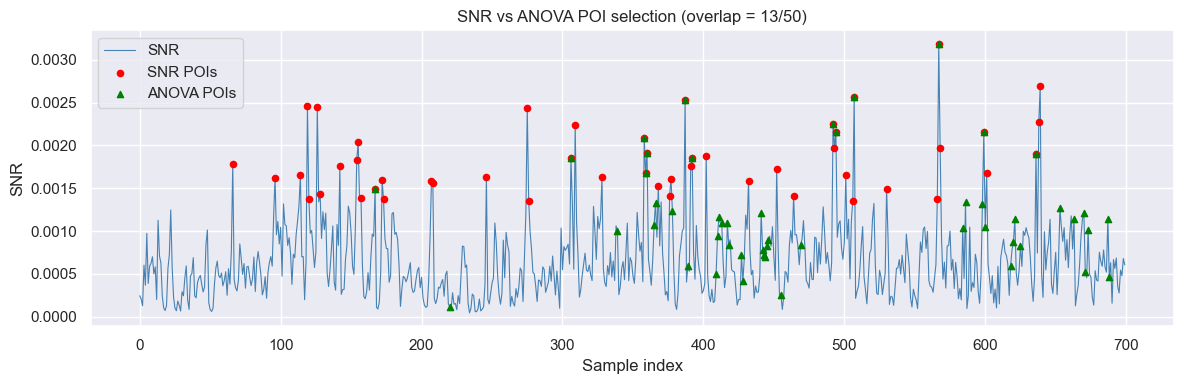

In [3]:
snr_idx   = results['snr']['transformer'].selected_indices
anova_idx = results['anova']['transformer'].selected_indices
overlap   = np.intersect1d(snr_idx, anova_idx)

print(f'SNR  top-50 indices  : {snr_idx[:10]} ...')
print(f'ANOVA top-50 indices : {anova_idx[:10]} ...')
print(f'Overlap (SNR ∩ ANOVA): {len(overlap)}/50 samples')

snr = compute_snr(X_prof, y_prof)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(snr, linewidth=0.8, color='steelblue', label='SNR')
ax.scatter(snr_idx,   snr[snr_idx],   color='red',   s=20, zorder=5, label='SNR POIs')
ax.scatter(anova_idx, snr[anova_idx], color='green', s=20,
            marker='^', zorder=5, label='ANOVA POIs')
ax.set_xlabel('Sample index')
ax.set_ylabel('SNR')
ax.set_title(f'SNR vs ANOVA POI selection (overlap = {len(overlap)}/50)')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/raw/plot_poi_comparison.png', dpi=150)
plt.show()

## 3. PCA

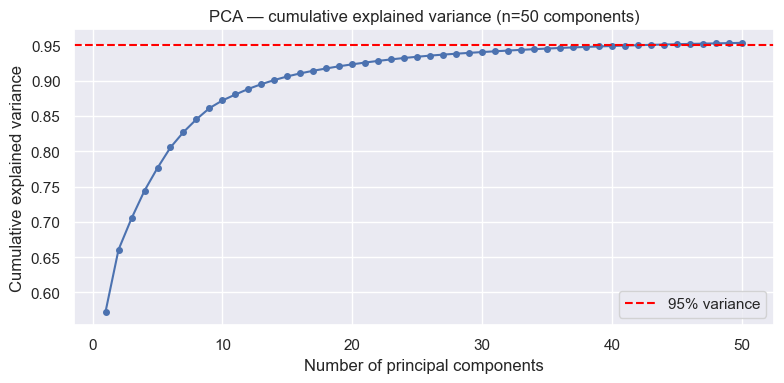

Variance explained by 50 PCs: 95.4%


In [5]:
pca_model = results['pca']['transformer']._selector
explained = np.cumsum(pca_model.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(explained)+1), explained, marker='o', markersize=4)
ax.axhline(0.95, color='red', linestyle='--', label='95% variance')
ax.set_xlabel('Number of principal components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA — cumulative explained variance (n=50 components)')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/raw/plot_pca_variance.png', dpi=150)
plt.show()
print(f'Variance explained by 50 PCs: {explained[-1]*100:.1f}%')

## 4. Effect of k

snr k= 20 → macro F1: 0.0873
anova k= 20 → macro F1: 0.0879
snr k= 50 → macro F1: 0.0889
anova k= 50 → macro F1: 0.0899
snr k=100 → macro F1: 0.0956
anova k=100 → macro F1: 0.0968
snr k=200 → macro F1: 0.1017
anova k=200 → macro F1: 0.1010


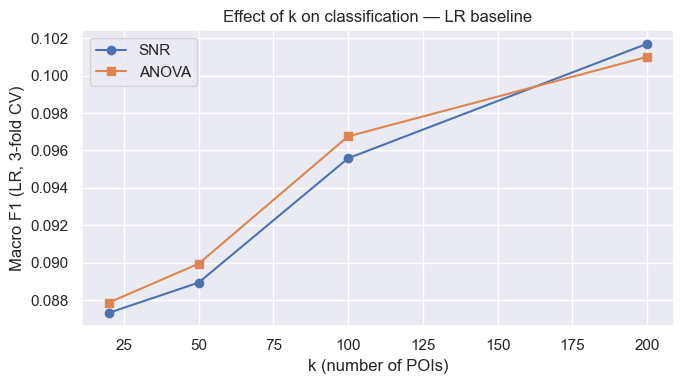

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

k_values = [20, 50, 100, 200]
cv_scores = {'snr': [], 'anova': []}

for k in k_values:
    for strategy in ['snr', 'anova']:
        cfg = DataTransformationConfig(strategy=strategy, k=k)
        dt  = DataTransformation(cfg)
        X_t, _, _ = dt.initiate_data_transformation(X_prof, y_prof, X_atk)
        # Use 5k subset for speed
        score = cross_val_score(
            LogisticRegression(max_iter=500, C=0.1),
            X_t[:5000], y_prof[:5000],
            cv=3, scoring='f1_macro', n_jobs=-1
        ).mean()
        cv_scores[strategy].append(score)
        print(f'{strategy} k={k:3d} → macro F1: {score:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, cv_scores['snr'],   marker='o', label='SNR')
ax.plot(k_values, cv_scores['anova'], marker='s', label='ANOVA')
ax.set_xlabel('k (number of POIs)')
ax.set_ylabel('Macro F1 (LR, 3-fold CV)')
ax.set_title('Effect of k on classification — LR baseline')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/raw/plot_k_sweep.png', dpi=150)
plt.show()